# Step 4 – Results Plotting — Shor's Algorithm Graph States

Loads completed results from `simulations_data/step4_results_shor_red/` and the graph database from `shor_graph_database/full/`, then produces the analysis of the simulated data.

In [19]:
import re
import pickle
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
from IPython.display import display

# ── Paths ──────────────────────────────────────────────────────────────────
RESULTS_DIR = pathlib.Path(
    "/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation"
    "/simulations_data/step4_results_shor_red"
)
DB_DIR = pathlib.Path("shor_graph_database/full")

ALGOS       = ["path_clust", "lrw", "lrw_sa", "saminla"]
ALGO_LABELS = {
    "path_clust": "Path Clustering",
    "lrw":        "Hill Climbing",
    "lrw_sa":     "Height Function SA",
    "saminla":    "Minimum LA SA",
}
ALGO_COLORS = ["#2196F3", "#FF9800", "#9C27B0", "#4CAF50"]


def _shor_sort_key(name: str):
    """Extract (N, a) from e.g. 'shor_N15_a7' for numeric sorting."""
    m = re.search(r"N(\d+)_a(\d+)", name)
    return (int(m.group(1)), int(m.group(2))) if m else (999, 999)


# ── Load all graphs from DB, merge with any available results ───────────────
rows = []
for graph_pkl in sorted(DB_DIR.glob("*.pkl"), key=lambda p: _shor_sort_key(p.stem)):
    graph_name = graph_pkl.stem
    with open(graph_pkl, "rb") as f:
        g: nx.Graph = pickle.load(f)
    n_vertices = g.number_of_nodes()
    n_edges    = g.number_of_edges()

    stem_dir = RESULTS_DIR / graph_name
    for algo in ALGOS:
        res_pkl = stem_dir / f"{algo}.pkl"
        if res_pkl.exists():
            with open(res_pkl, "rb") as f:
                res = pickle.load(f)
            rows.append({
                "graph":           graph_name,
                "algo":            algo,
                "vertices":        n_vertices,
                "edges":           n_edges,
                "emitters":        res.get("emitters"),
                "cnots":           res.get("cnots"),
                "gates":           res.get("gates"),
                "ordering_time_s": res.get("ordering_time_s"),
                "status":          "done",
            })
        else:
            rows.append({
                "graph":           graph_name,
                "algo":            algo,
                "vertices":        n_vertices,
                "edges":           n_edges,
                "emitters":        float("nan"),
                "cnots":           float("nan"),
                "gates":           float("nan"),
                "ordering_time_s": float("nan"),
                "status":          "pending",
            })

df = pd.DataFrame(rows)

# Graphs where every algorithm has a result
all_graphs_sorted = sorted(df["graph"].unique(), key=_shor_sort_key)
done_set = {
    g for g in all_graphs_sorted
    if df[df["graph"] == g]["status"].eq("done").all()
}
df_done = df[df["graph"].isin(done_set)].copy()

n_total   = len(all_graphs_sorted)
n_done    = len(done_set)
n_pending = n_total - n_done
print(f"Shor database : {n_total} graphs  |  {n_done} fully done  |  {n_pending} still pending")
df_done.head(8)

Shor database : 33 graphs  |  23 fully done  |  10 still pending


,graph,algo,vertices,edges,emitters,cnots,gates,ordering_time_s,status
0,shor_N3_a2,path_clust,18,44,2.0,4.0,33.0,4.418250,done
1,shor_N3_a2,lrw,18,44,2.0,4.0,33.0,1.037348,done
2,shor_N3_a2,lrw_sa,18,44,2.0,4.0,33.0,5.586309,done
3,shor_N3_a2,saminla,18,44,3.0,5.0,30.0,1.711008,done
4,shor_N4_a3,path_clust,7,6,1.0,0.0,8.0,1.435187,done
5,shor_N4_a3,lrw,7,6,1.0,0.0,8.0,0.084550,done
6,shor_N4_a3,lrw_sa,7,6,1.0,0.0,8.0,1.929339,done
7,shor_N4_a3,saminla,7,6,1.0,0.0,8.0,0.444401,done


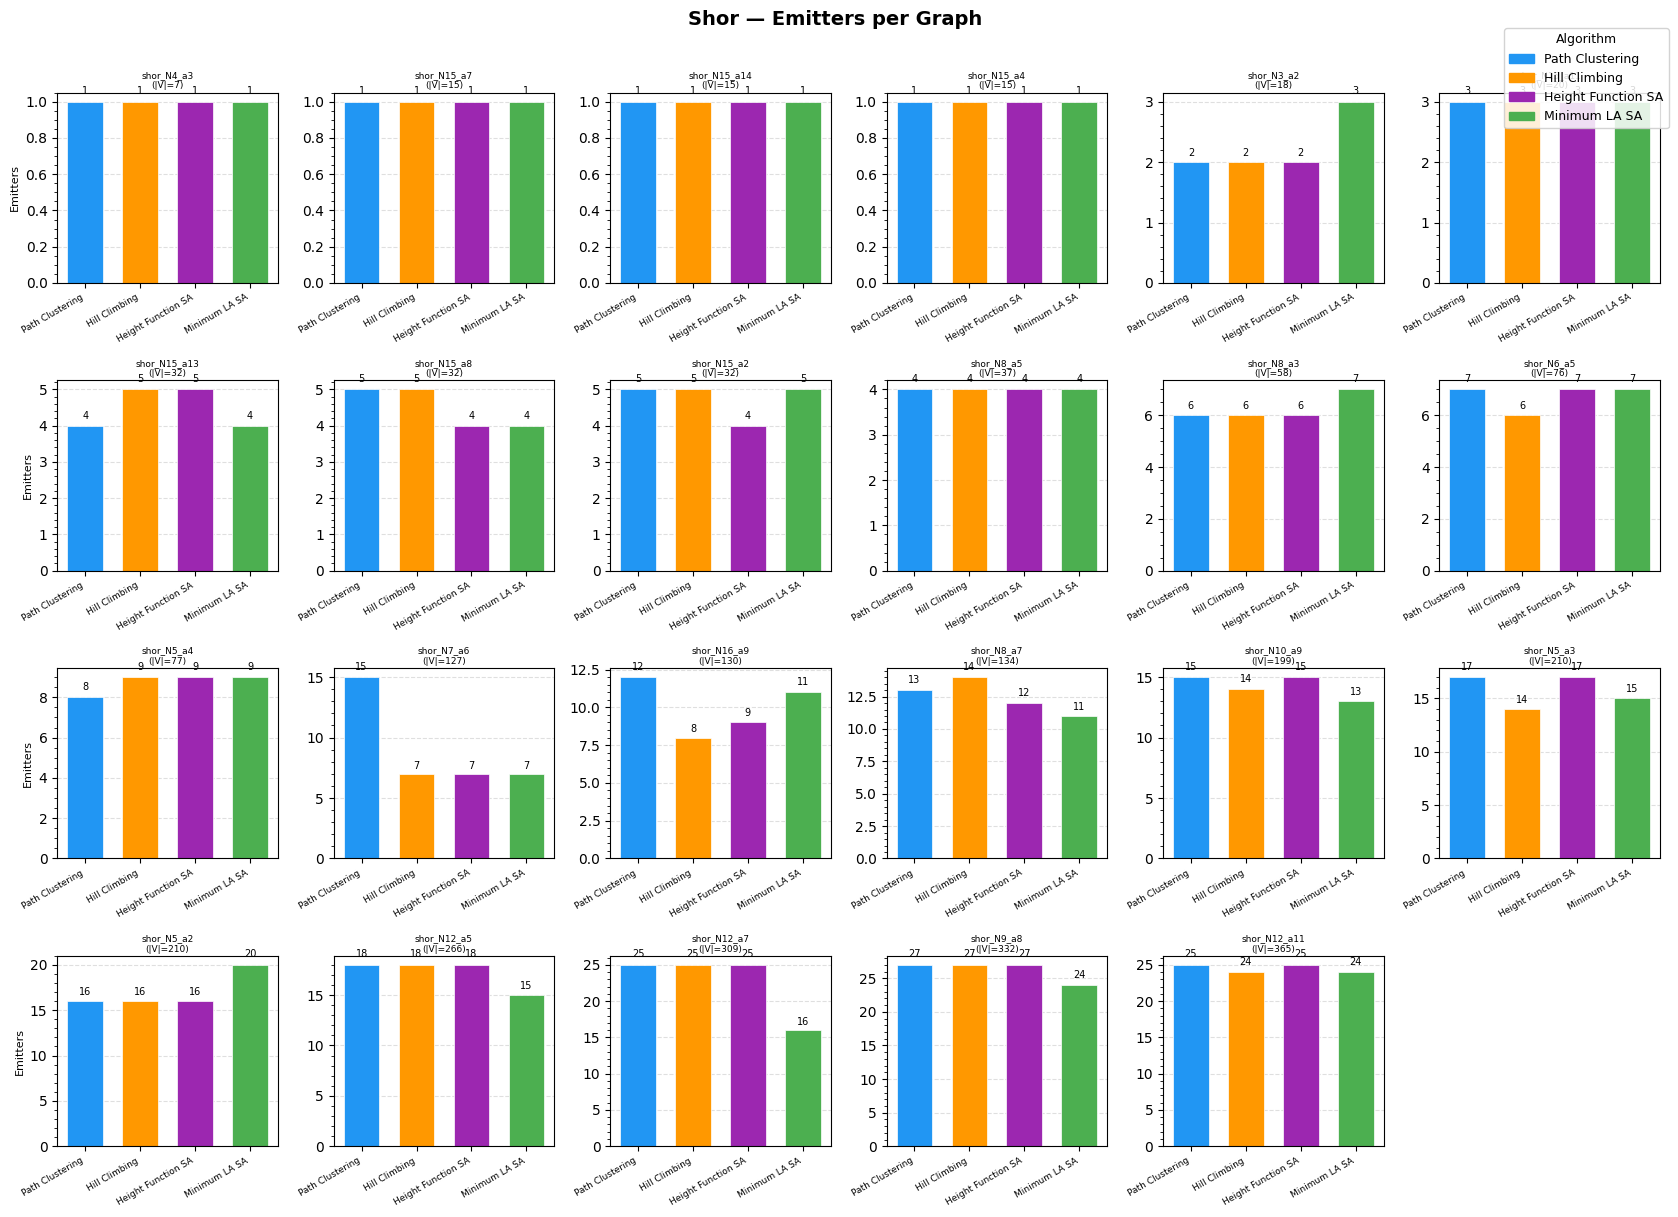

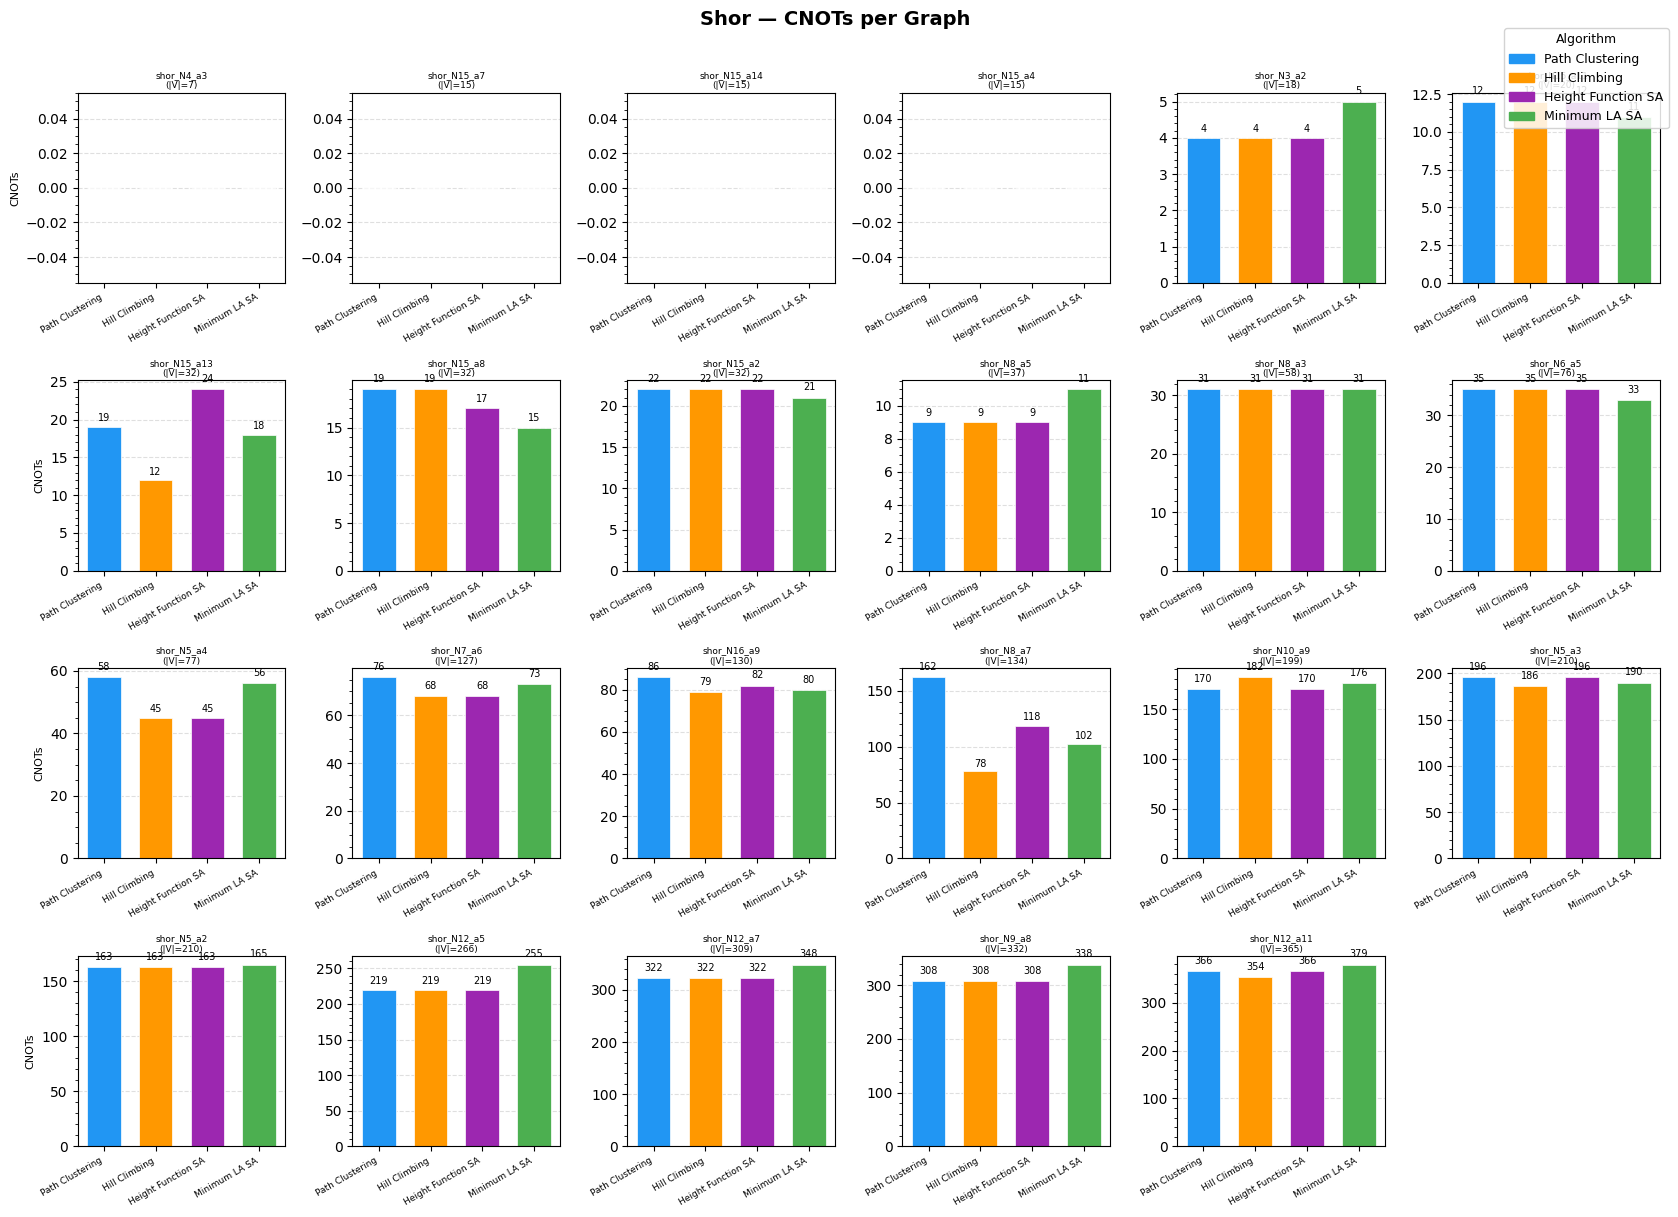

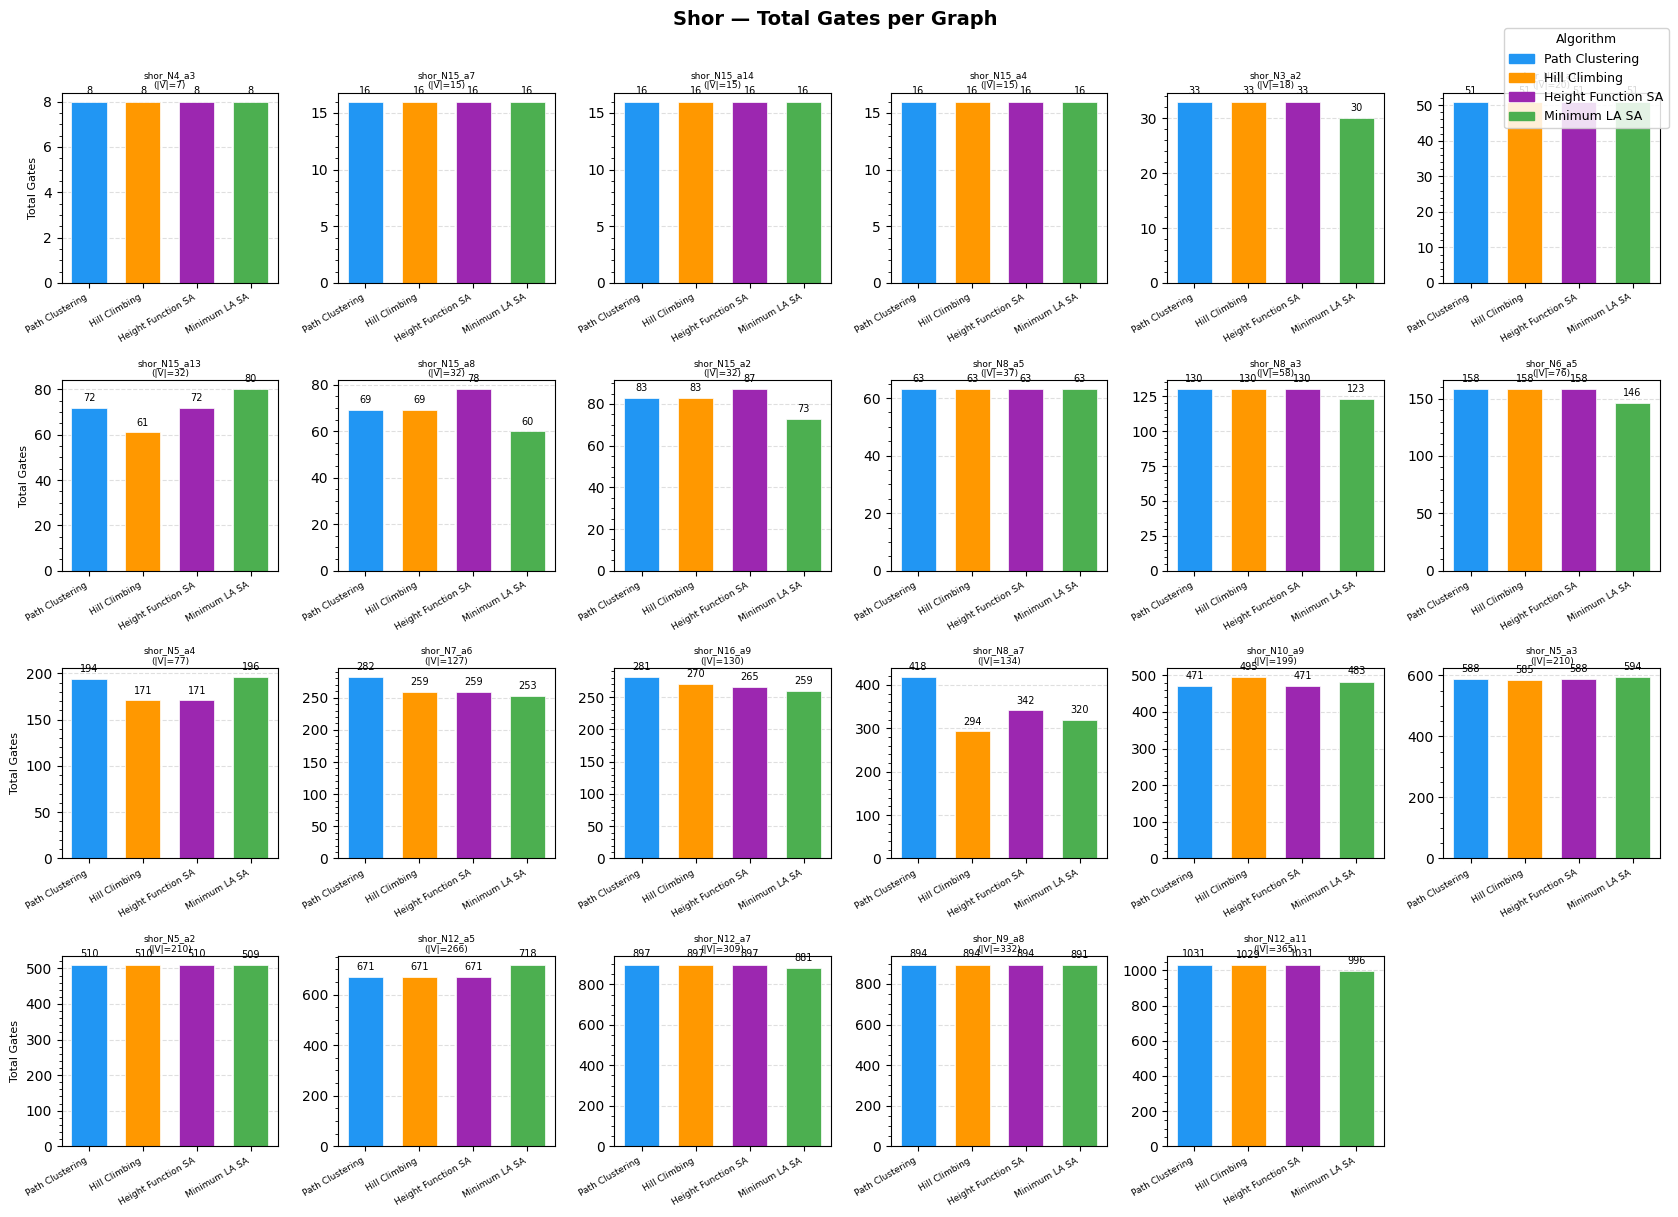

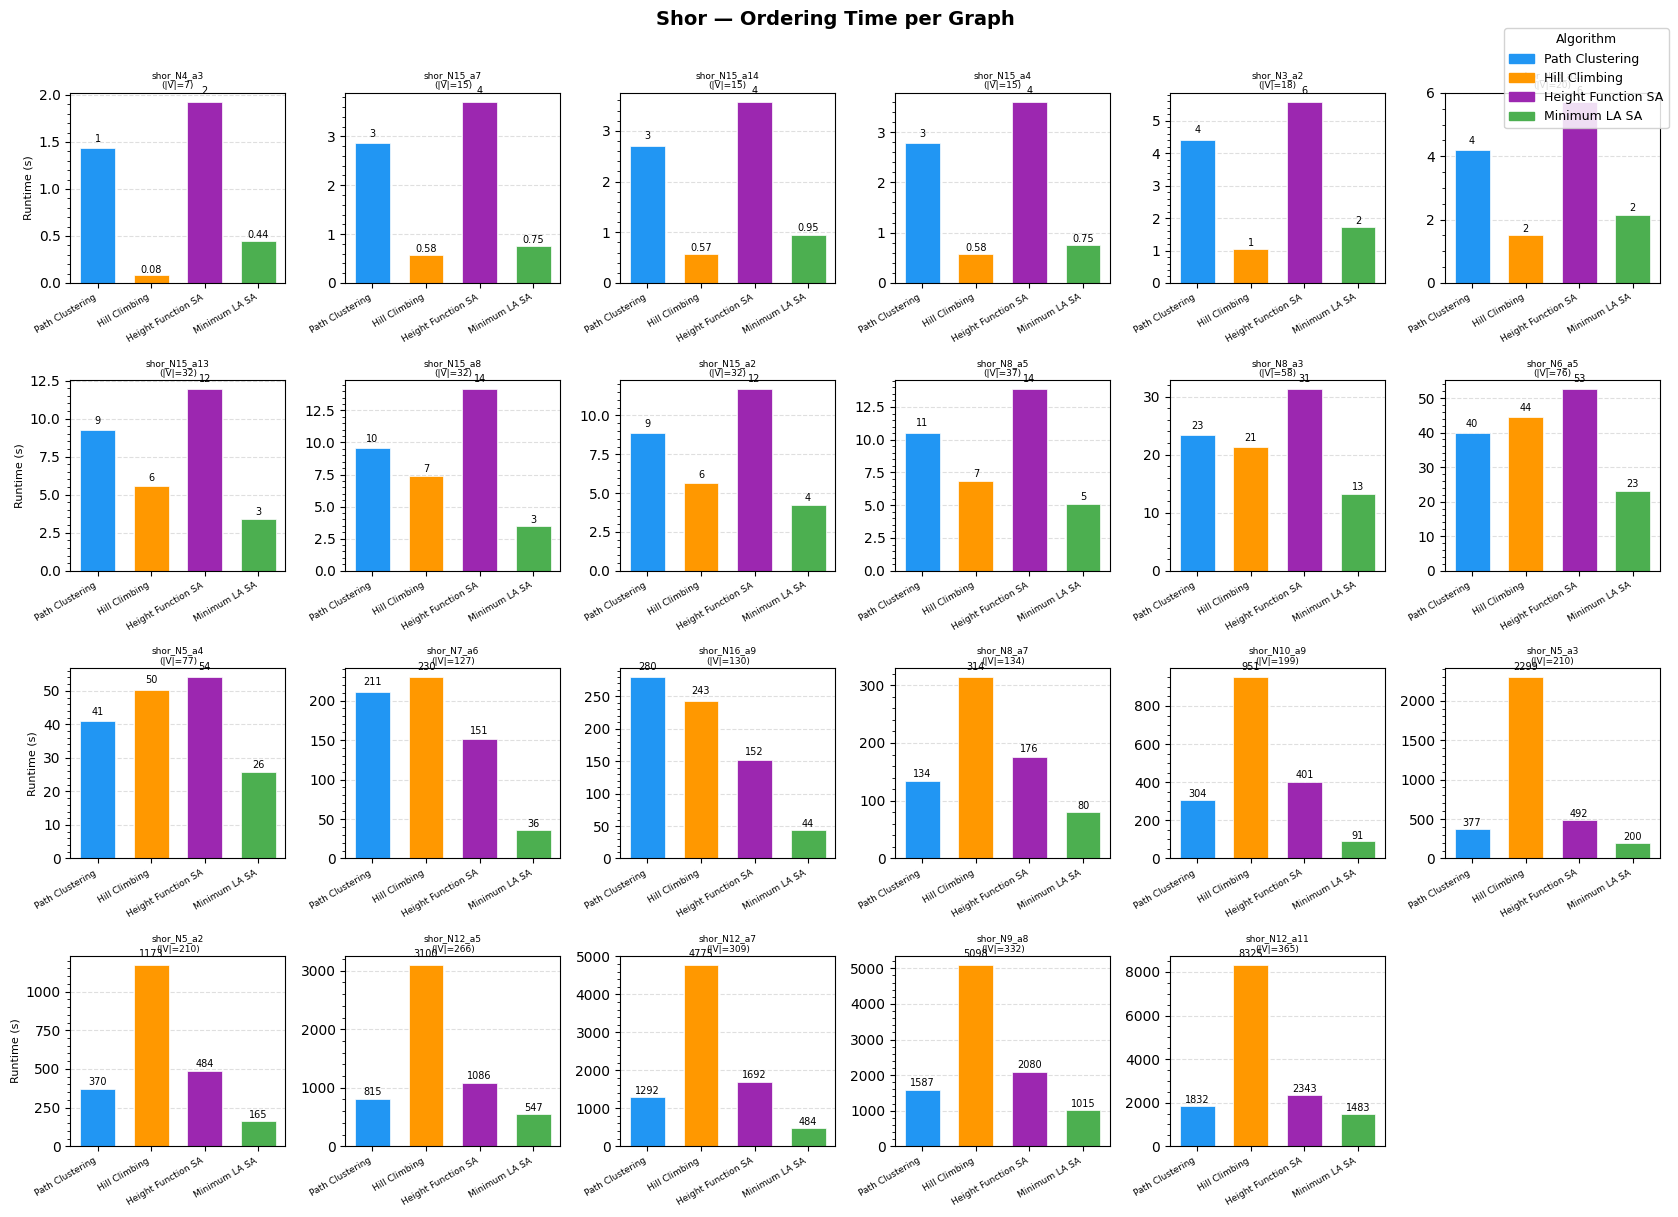

In [20]:
# ── Metric bar charts — one subplot per completed graph ─────────────────────
# Each subplot has its own y-scale so small graphs are not dwarfed by large ones.

def plot_metric_per_graph(df_in: pd.DataFrame, metric: str,
                          ylabel: str, title: str) -> None:
    """
    One subplot per completed graph, sorted by vertex count.
    Within each subplot the four algorithm bars share a common y-axis
    (auto-scaled to that graph's values).
    """
    order = (
        df_in[df_in["status"] == "done"][["graph", "vertices"]]
        .drop_duplicates()
        .sort_values("vertices")["graph"]
        .tolist()
    )
    if not order:
        print(f"No completed data for '{metric}'.")
        return

    n_graphs  = len(order)
    ncols     = min(6, n_graphs)
    nrows     = int(np.ceil(n_graphs / ncols))
    x         = np.arange(len(ALGOS))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 2.8, nrows * 3.0),
        squeeze=False,
    )
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)

    for idx, graph_name in enumerate(order):
        row_i, col_i = divmod(idx, ncols)
        ax = axes[row_i][col_i]

        sub = df_in[(df_in["graph"] == graph_name) & (df_in["status"] == "done")]
        vals = []
        for algo in ALGOS:
            row = sub[sub["algo"] == algo]
            vals.append(float(row[metric].values[0]) if not row.empty and pd.notna(row[metric].values[0]) else 0.0)

        bars = ax.bar(x, vals, width=0.65,
                      color=ALGO_COLORS, edgecolor="white", linewidth=0.5)

        for bar, v in zip(bars, vals):
            if v > 0:
                fmt = f"{v:.0f}" if v >= 1 else f"{v:.2f}"
                ax.text(bar.get_x() + bar.get_width() / 2, v * 1.03,
                        fmt, ha="center", va="bottom", fontsize=7)

        n_v = int(sub["vertices"].values[0]) if not sub.empty else "?"
        ax.set_title(f"{graph_name}\n(|V|={n_v})", fontsize=6.5, pad=3)
        ax.set_xticks(x)
        ax.set_xticklabels([ALGO_LABELS[a] for a in ALGOS],
                           rotation=30, ha="right", fontsize=6.5)
        ax.set_ylabel(ylabel if col_i == 0 else "", fontsize=8)
        ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
        ax.grid(axis="y", which="major", linestyle="--", alpha=0.4)
        ax.set_axisbelow(True)

    # hide unused subplots
    for idx in range(n_graphs, nrows * ncols):
        row_i, col_i = divmod(idx, ncols)
        axes[row_i][col_i].set_visible(False)

    # shared legend
    handles = [mpatches.Patch(color=c, label=ALGO_LABELS[a])
               for a, c in zip(ALGOS, ALGO_COLORS)]
    fig.legend(handles=handles, title="Algorithm",
               loc="upper right", bbox_to_anchor=(1.0, 1.0),
               fontsize=9, title_fontsize=9, framealpha=0.85)

    plt.tight_layout()
    plt.show()


plot_metric_per_graph(df_done, "emitters",        "Emitters",        "Shor — Emitters per Graph")
plot_metric_per_graph(df_done, "cnots",           "CNOTs",           "Shor — CNOTs per Graph")
plot_metric_per_graph(df_done, "gates",           "Total Gates",     "Shor — Total Gates per Graph")
plot_metric_per_graph(df_done, "ordering_time_s", "Runtime (s)",   "Shor — Ordering Time per Graph")

## Shor Summary Table

One row per *(completed graph × algorithm)*, sorted by vertex count.
Columns: **Graph**, **|V|**, **|E|**, **Algorithm**, **Emitters**, **CNOTs**, **Gates**, **Runtime (s)**.

In [21]:
# ── Shor Summary Table (completed graphs only) ─────────────────────────────
table = (
    df_done[["graph", "vertices", "edges", "algo",
             "emitters", "cnots", "gates", "ordering_time_s"]]
    .copy()
    .sort_values(["vertices", "graph", "algo"])
    .reset_index(drop=True)
)
table["algo"] = table["algo"].map(ALGO_LABELS)
for col in ["emitters", "cnots", "gates"]:
    table[col] = table[col].apply(lambda v: str(int(v)) if pd.notna(v) else "—")
table["ordering_time_s"] = table["ordering_time_s"].apply(
    lambda v: f"{v:.2f}" if (v is not None and pd.notna(v)) else "—"
)
table.columns = ["Graph", "|V|", "|E|", "Algorithm",
                 "Emitters", "CNOTs", "Gates", "Runtime (s)"]

styled = (
    table.style
    .set_caption(
        f"Shor Benchmark — {n_done} completed graphs × {len(ALGOS)} algorithms"
    )
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "13px"), ("font-weight", "bold"), ("padding-bottom", "8px")]},
        {"selector": "th",
         "props": [("background-color", "#2c3e50"), ("color", "white"),
                   ("text-align", "center"), ("padding", "6px 10px")]},
        {"selector": "td",
         "props": [("text-align", "center"), ("padding", "4px 10px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background-color", "#f9f9f9")]},
    ])
)
display(styled)

,Graph,|V|,|E|,Algorithm,Emitters,CNOTs,Gates,Runtime (s)
0,shor_N4_a3,7,6,Hill Climbing,1,0,8,0.08
1,shor_N4_a3,7,6,Height Function SA,1,0,8,1.93
2,shor_N4_a3,7,6,Path Clustering,1,0,8,1.44
3,shor_N4_a3,7,6,Minimum LA SA,1,0,8,0.44
4,shor_N15_a14,15,14,Hill Climbing,1,0,16,0.57
5,shor_N15_a14,15,14,Height Function SA,1,0,16,3.58
6,shor_N15_a14,15,14,Path Clustering,1,0,16,2.71
7,shor_N15_a14,15,14,Minimum LA SA,1,0,16,0.95
8,shor_N15_a4,15,14,Hill Climbing,1,0,16,0.58
9,shor_N15_a4,15,14,Height Function SA,1,0,16,3.60


## Shor — Algorithm Comparison

**Plot D** – For each metric, which algorithm achieves the minimum value on the most Shor graphs?

**Plot E** – Normalised radar chart: each algorithm's average rank (1 = best, 4 = worst) across all metrics and graphs.

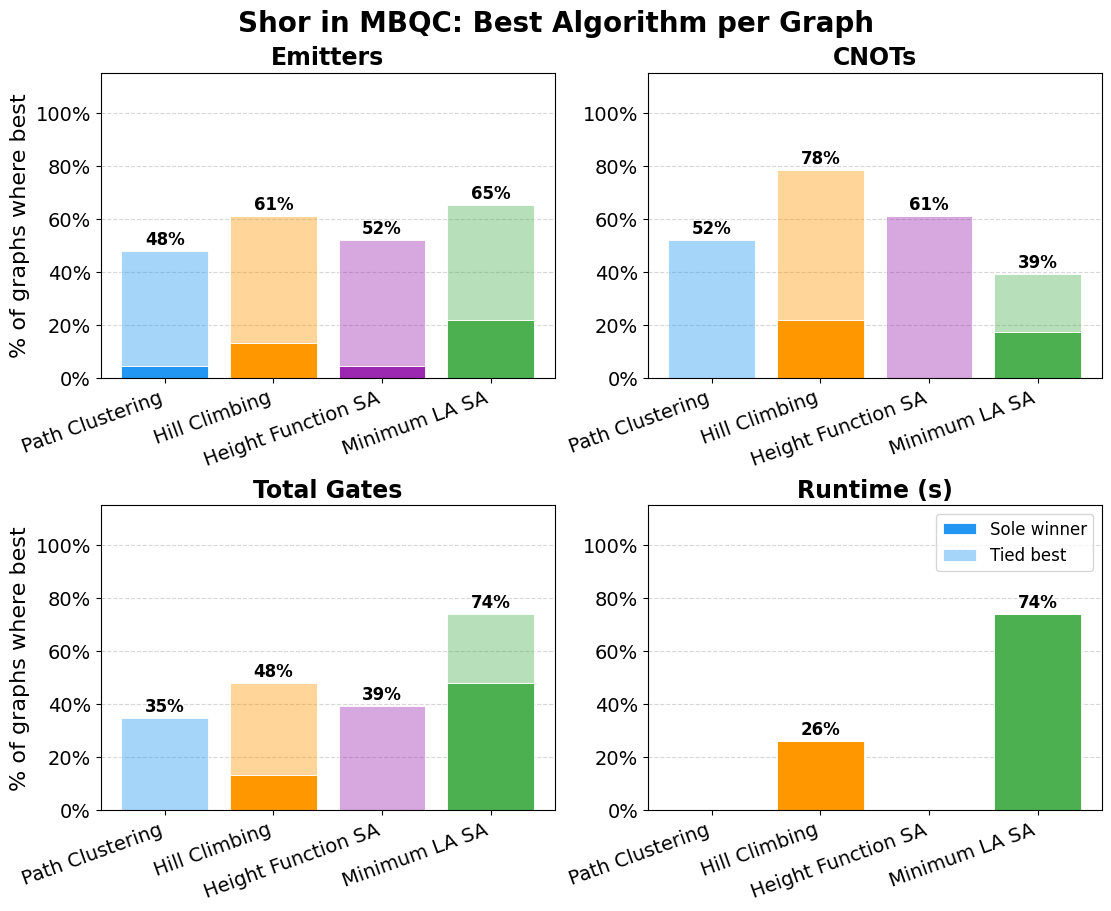

In [22]:
# ── Plot D  (Shor) — which algorithm wins most graphs per metric ──────────────

LABEL_SIZE = 16
TITLE_SIZE = 17
TICK_SIZE = 14
BAR_TEXT_SIZE = 12
LEGEND_SIZE = 12
SUPTITLE_SIZE = 20

METRICS_SHOR = [
    ("emitters",        "Emitters"),
    ("cnots",           "CNOTs"),
    ("gates",           "Total Gates"),
    ("ordering_time_s", "Runtime (s)"),
]

nrows, ncols = 2, 2

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(11, 9),
    sharey=False,
    constrained_layout=True
)

axes_flat = axes.flatten()

fig.suptitle(
    "Shor in MBQC: Best Algorithm per Graph",
    fontsize=SUPTITLE_SIZE,
    fontweight="bold"
)

for idx, ((metric, mlabel), ax) in enumerate(zip(METRICS_SHOR, axes_flat)):
    wins = {a: 0 for a in ALGOS}
    ties = {a: 0 for a in ALGOS}
    n_compared = 0

    for graph_name in done_set:
        sub = df_done[df_done["graph"] == graph_name]

        vals = {
            row["algo"]: row[metric]
            for _, row in sub.iterrows()
            if pd.notna(row[metric])
        }

        if not vals:
            continue

        best = min(vals.values())

        winners = [
            a
            for a, v in vals.items()
            if v == best
        ]

        n_compared += 1

        for a in winners:
            if len(winners) == 1:
                wins[a] += 1
            else:
                ties[a] += 1

    pct_wins = [
        wins[a] / n_compared * 100 if n_compared else 0
        for a in ALGOS
    ]

    pct_ties = [
        ties[a] / n_compared * 100 if n_compared else 0
        for a in ALGOS
    ]

    x = np.arange(len(ALGOS))

    bars_w = ax.bar(
        x,
        pct_wins,
        color=ALGO_COLORS,
        edgecolor="white",
        linewidth=0.6,
        label="Sole winner"
    )

    bars_t = ax.bar(
        x,
        pct_ties,
        bottom=pct_wins,
        color=[c + "66" for c in ALGO_COLORS],
        edgecolor="white",
        linewidth=0.6,
        label="Tied best"
    )

    for bar, pw, pt in zip(bars_w, pct_wins, pct_ties):
        total = pw + pt

        if total > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                total + 1.0,
                f"{total:.0f}%",
                ha="center",
                va="bottom",
                fontsize=BAR_TEXT_SIZE,
                fontweight="bold"
            )

    ax.set_xticks(x)

    ax.set_xticklabels(
        [ALGO_LABELS[a] for a in ALGOS],
        fontsize=TICK_SIZE,
        rotation=20,
        ha="right"
    )

    ax.set_title(
        mlabel,
        fontsize=TITLE_SIZE,
        fontweight="bold"
    )

    ax.set_ylabel(
        "% of graphs where best" if idx % ncols == 0 else "",
        fontsize=LABEL_SIZE
    )

    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE
    )

    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.5
    )

    ax.set_axisbelow(True)

    if idx == len(METRICS_SHOR) - 1:
        ax.legend(
            fontsize=LEGEND_SIZE,
            loc="upper right"
        )

plt.show()

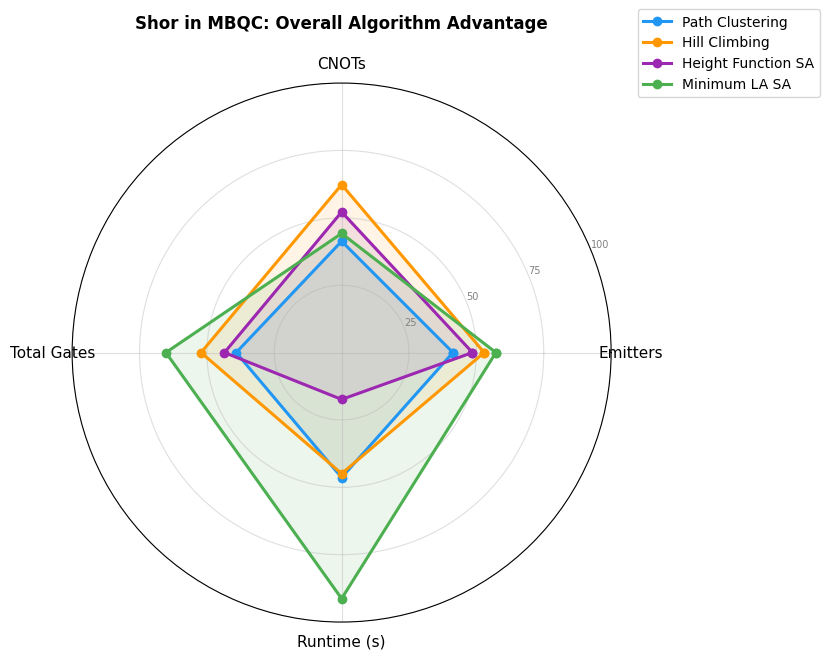

In [23]:
# ── Plot E  (Shor) — normalised radar chart ─────────────────────────────────
# For each graph×metric, rank algorithms 1–4 (1=best). Average rank → radar.

radar_metrics = [m for m, _ in METRICS_SHOR]
radar_labels  = [l for _, l in METRICS_SHOR]
N_radar = len(radar_metrics)

rank_data = {a: [] for a in ALGOS}
for metric in radar_metrics:
    ranks_per_graph = []
    for graph_name in done_set:
        sub = df_done[df_done["graph"] == graph_name]
        vals = {row["algo"]: row[metric]
                for _, row in sub.iterrows()
                if pd.notna(row[metric])}
        if len(vals) < 2:
            continue
        sorted_algos = sorted(vals, key=lambda a: vals[a])
        rank_map = {}
        r = 1
        i = 0
        while i < len(sorted_algos):
            j = i
            while j < len(sorted_algos) - 1 and vals[sorted_algos[j+1]] == vals[sorted_algos[j]]:
                j += 1
            avg_r = (r + r + (j - i)) / 2
            for k in range(i, j + 1):
                rank_map[sorted_algos[k]] = avg_r
            r += (j - i + 1)
            i = j + 1
        ranks_per_graph.append(rank_map)
    for a in ALGOS:
        arr = [rg[a] for rg in ranks_per_graph if a in rg]
        rank_data[a].append(np.mean(arr) if arr else np.nan)

# Normalise: 1=best → 100%, 4=worst → 0%  (so larger = better on radar)
def rank_to_score(rank):
    return (4 - rank) / 3 * 100  # 1→100, 4→0

angles = np.linspace(0, 2 * np.pi, N_radar, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for a, color in zip(ALGOS, ALGO_COLORS):
    scores = [rank_to_score(r) if not np.isnan(r) else 0 for r in rank_data[a]]
    scores += scores[:1]
    ax.plot(angles, scores, color=color, linewidth=2.2,
            label=ALGO_LABELS[a], marker='o', markersize=6)
    ax.fill(angles, scores, color=color, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(['25', '50', '75', '100'], fontsize=7, color='grey')

ax.set_title('Shor in MBQC: Overall Algorithm Advantage',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.40, 1.15), fontsize=10)
ax.grid(True, alpha=0.4)

plt.show()

## LaTeX Table Export

Exports the Shor summary table as `latex/table_shor.tex` ready for inclusion in a paper.
Run the cell below to (re-)generate the file.

In [24]:
# ── LaTeX export ──────────────────────────────────────────────────────────────
LATEX_OUT = pathlib.Path("latex")
LATEX_OUT.mkdir(exist_ok=True)


def _escape(s: str) -> str:
    """Escape LaTeX special characters in a string."""
    for ch, rep in [("_", r"\_"), ("#", r"\#"), ("%", r"\%"), ("&", r"\&")]:
        s = str(s).replace(ch, rep)
    return s


def df_to_latex(df_in: pd.DataFrame, caption: str, label: str) -> str:
    """Convert a plain DataFrame to a LaTeX longtable string."""
    cols = df_in.columns.tolist()
    n_cols = len(cols)
    col_spec = "l" + "r" * (n_cols - 1)

    lines = [
        r"\begin{longtable}{" + col_spec + "}",
        r"  \caption{" + caption + r"} \label{" + label + r"} \\",
        r"  \toprule",
        "  " + " & ".join(f"\\textbf{{{_escape(c)}}}" for c in cols) + r" \\",
        r"  \midrule",
        r"  \endfirsthead",
        r"  \multicolumn{" + str(n_cols) + r"}{c}{\tablename\ \thetable{} (continued)} \\",
        r"  \toprule",
        "  " + " & ".join(f"\\textbf{{{_escape(c)}}}" for c in cols) + r" \\",
        r"  \midrule",
        r"  \endhead",
        r"  \midrule \multicolumn{" + str(n_cols) + r"}{r}{\textit{continued on next page}} \\",
        r"  \endfoot",
        r"  \bottomrule",
        r"  \endlastfoot",
    ]

    for _, row in df_in.iterrows():
        lines.append("  " + " & ".join(_escape(str(v)) for v in row.values) + r" \\")

    lines.append(r"\end{longtable}")
    return "\n".join(lines)


# ── Shor table ────────────────────────────────────────────────────────────────
shor_tex_df = (
    df_done[["graph", "vertices", "edges", "algo",
             "emitters", "cnots", "gates", "ordering_time_s"]]
    .copy()
    .sort_values(["vertices", "graph", "algo"])
    .reset_index(drop=True)
)
shor_tex_df["algo"] = shor_tex_df["algo"].map(ALGO_LABELS)
for col in ["emitters", "cnots", "gates"]:
    shor_tex_df[col] = shor_tex_df[col].apply(
        lambda v: str(int(v)) if pd.notna(v) else r"\textemdash"
    )
shor_tex_df["ordering_time_s"] = shor_tex_df["ordering_time_s"].apply(
    lambda v: f"{v:.2f}" if (v is not None and pd.notna(v)) else r"\textemdash"
)
shor_tex_df.columns = ["Graph", "|V|", "|E|", "Algorithm",
                       "Emitters", "CNOTs", "Gates", "Runtime (s)"]

shor_tex = df_to_latex(
    shor_tex_df,
    caption=f"Shor benchmark results — {n_done} completed graphs × {len(ALGOS)} algorithms.",
    label="tab:shor_results",
)
(LATEX_OUT / "table_shor.tex").write_text(shor_tex)
print(f"Wrote {LATEX_OUT / 'table_shor.tex'}  ({len(shor_tex_df)} rows)")

print("\nInclude in LaTeX with:")
print(r"  \usepackage{longtable, booktabs}")
print(r"  \input{latex/table_shor.tex}")

Wrote latex/table_shor.tex  (92 rows)

Include in LaTeX with:
  \usepackage{longtable, booktabs}
  \input{latex/table_shor.tex}
